In [69]:
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
tx = pd.read_excel('T212TradingData.xlsx', sheet_name='Transactions')
tx

,Time (UTC),Ticker,Name,Type,Buy/Sell,Quantity,Currency (Price / share),Price,Price (£),Total (£)
0,2025-09-02 10:34:31+00:00,ASML,ASML,Trade,Sell,0.234680,EUR,621.80,534.7480,125.494538
1,2025-09-02 13:30:14+00:00,GOOGL,Alphabet (Class A),Trade,Sell,1.109645,USD,208.26,156.1950,173.321015
2,2025-09-02 13:30:14+00:00,AMD,Advanced Micro Devices,Trade,Sell,1.175097,USD,158.00,118.5000,139.249030
3,2025-09-02 13:30:15+00:00,TSLA,Tesla,Trade,Sell,0.457808,USD,328.07,246.0525,112.644768
4,2025-09-02 13:30:15+00:00,META,Meta Platforms,Trade,Sell,0.341816,USD,725.00,543.7500,185.862233
...,...,...,...,...,...,...,...,...,...,...
180,2025-10-07 16:28:29+00:00,MSTR,Strategy,Trade,Sell,3.312849,USD,332.88,249.6600,827.085799
181,2025-10-07 16:29:19+00:00,META,Meta Platforms,Trade,Buy,1.325460,USD,708.98,531.7350,704.793218
182,2025-10-07 16:30:46+00:00,FIG,Figma,Trade,Buy,14.375740,USD,60.70,45.5250,654.455542
183,2025-10-07 16:30:48+00:00,MELI,MercadoLibre,Trade,Buy,0.375123,USD,2147.27,1610.4525,604.117451


In [71]:
#Top 10 biggest Stock buys
Trades = tx[tx['Type'] == 'Trade'].copy()
summary = Trades.groupby('Ticker').agg(
    numOfTrades = ('Ticker', 'count'),
    totalSpent = ('Total (£)', 'sum'),
    averageTradeSize = ('Total (£)', 'mean')
).reset_index()

print(summary.sort_values('totalSpent', ascending=False).head(10))

   Ticker  numOfTrades   totalSpent  averageTradeSize
34   META            4  1808.889077        452.222269
36   MSTR            2  1577.172713        788.586356
53   SPOT            2  1323.239408        661.619704
20    FIG            4  1107.326631        276.831658
38   NFLX            1  1067.844423       1067.844423
33   MELI            2  1004.687682        502.343841
5    AVGO            1   799.504940        799.504940
2    AMZN            3   777.845650        259.281883
41   ORCL            2   709.874607        354.937303
25    IBM            3   609.183287        203.061096


In [ ]:
# Findings:
# META, MSTR and SPOT were my three largest positions by money traded in this window,
# with META alone accounting for ~£1,800 of activity — worth noting these are also among my more concentrated/volatile picks.

In [72]:
# Buy vs Sell price per Ticker pivot table

wide = Trades.pivot_table(
    index='Ticker',
    columns = 'Buy/Sell',
    values = 'Price (£)',
    aggfunc = 'mean',
)
print(wide.dropna())


Buy/Sell        Buy       Sell
Ticker                        
AV          6.32600    6.38100
AZN       119.94000  122.10000
BA         17.66000   17.58750
BARC        3.59300    3.64500
BATS       40.90000   40.80500
BNZL       25.06000   25.47000
BP          4.33800    4.25550
CRDA       24.69000   24.54500
DGE        20.49000   20.38500
EXPN       37.90000   38.29500
GOOGL     177.49875  156.19500
GSK        14.67500   14.60500
HLN         3.67000    3.71650
HSBA        9.48000    9.51750
IBM       198.13500  211.80000
IGG        10.99000   11.21000
IMB        30.79000   30.77500
ISF         8.95800    9.01650
IUSA       47.56000   47.90125
LLOY        0.78180    0.79650
LSEG       91.40000   92.49000
META      550.90500  543.75000
MSTR      226.41750  249.66000
NG         10.08000   10.28250
NVDA      134.05875  127.38750
PSN        10.35500   10.70250
REL        34.31000   34.36000
RIO        45.77000   46.48250
RR         10.69000   10.70500
SGE        10.68500   10.76750
SHEL    

In [73]:
# Most dividends by Ticker
dividends = tx[tx['Type'] == 'Dividend']
div_by_ticker = dividends.groupby('Ticker')['Total (£)'].sum().sort_values(ascending = False)

print(div_by_ticker)

Ticker
UNH      3.555150
IBM      2.932886
META     0.548364
RR       0.398842
NEE      0.292917
ULVR     0.272337
BP       0.266396
MSFT     0.245500
SHEL     0.217014
BARC     0.180919
BAB      0.161920
CHG      0.156040
CRDA     0.147962
LLOY     0.136041
AZN      0.123525
IMB      0.122665
RIO      0.102366
HSBA     0.100462
GOOGL    0.065902
BWXT     0.054579
CEG      0.045094
HLN      0.026589
REL      0.022000
LSEG     0.020525
NVDA     0.005248
Name: Total (£), dtype: float64


In [ ]:
# Findings:
# Dividend income was minimal in this window (£10.09 total), concentrated in UNH and IBM — expected,
# since this is a growth-tilted, recently-funded portfolio rather than an income strategy.


In [74]:
spend = Trades.groupby('Ticker')['Total (£)'].sum().sort_values(ascending=False).head(8)
spend

Ticker
META    1808.889077
MSTR    1577.172713
SPOT    1323.239408
FIG     1107.326631
NFLX    1067.844423
MELI    1004.687682
AVGO     799.504940
AMZN     777.845650
Name: Total (£), dtype: float64

In [ ]:
# Findings:
# All capital in this window (£2,250) was deposited in a single week in September 2025, showing a lump-sum funding approach 
# rather than regular drip-feeding — a deliberate choice worth mentioning if asked about my investing style.

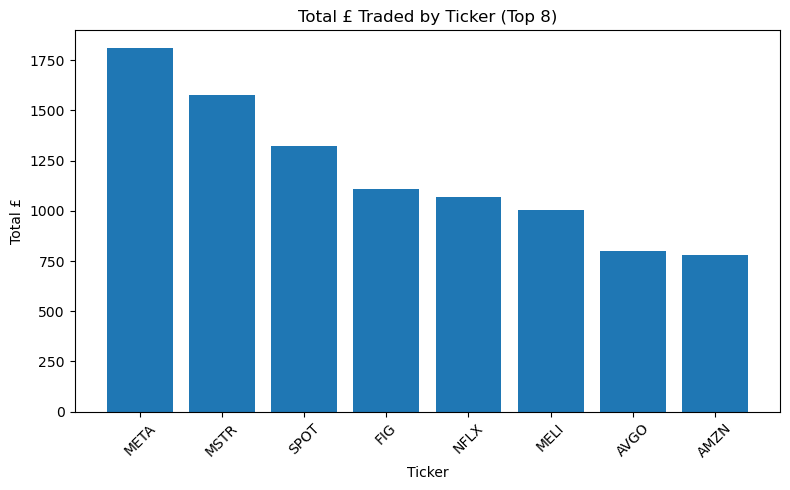

In [75]:
plt.figure(figsize=(8,5))
plt.bar(spend.index, spend.values)
plt.title('Total £ Traded by Ticker (Top 8)')
plt.xlabel('Ticker'); plt.ylabel('Total £')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Findings:
# META, MSTR and SPOT were my three largest positions by money traded in this window, with META alone
# accounting for ~£1,800 of activity — worth noting these are also among my more concentrated/volatile picks.


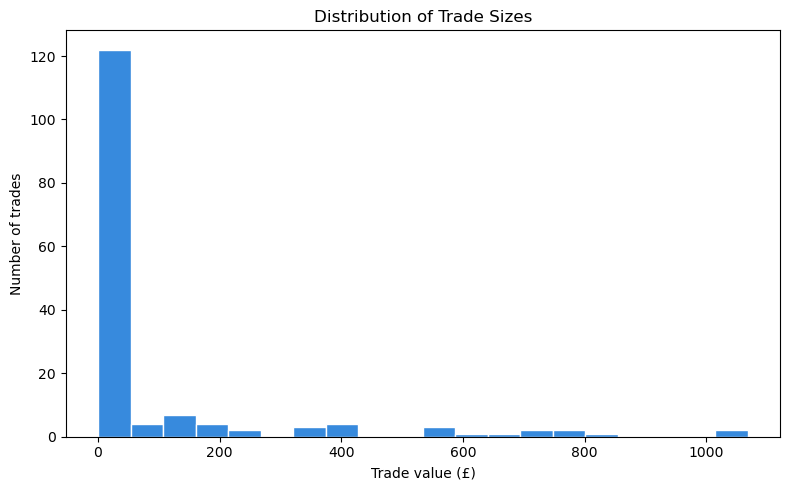

In [79]:
#Distribution of trade sizes 
plt.figure(figsize=(8,5))
plt.hist(Trades['Total (£)'], bins=20, color='#378ADD', edgecolor='white')
plt.title('Distribution of Trade Sizes')
plt.xlabel('Trade value (£)')
plt.ylabel('Number of trades')
plt.tight_layout()
plt.show()

In [ ]:
# Findings:
# The median trade was small (£17.37), but a handful of trades exceeded £800–£1,000, 
# showing a barbell pattern: frequent small adjustments alongside occasional larger conviction trades.

In [78]:
Trades['Time (UTC)'] = pd.to_datetime(Trades['Time (UTC)'])
Trades['Weekday'] = Trades['Time (UTC)'].dt.day_name()
by_day = Trades.groupby('Weekday')['Ticker'].count().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

Weekday
Monday        2.0
Tuesday      56.0
Wednesday    10.0
Thursday     90.0
Friday        NaN
Saturday      NaN
Sunday        NaN
Name: Ticker, dtype: float64

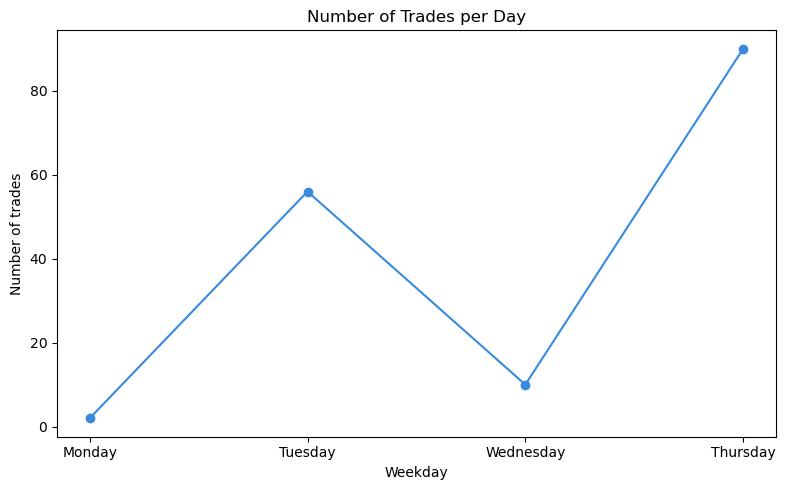

In [81]:
plt.figure(figsize=(8,5))
plt.plot(by_day.index, by_day.values, marker='o', color='#378ADD')
plt.title('Number of Trades per Day')
plt.xlabel('Weekday')
plt.ylabel('Number of trades')
plt.tight_layout()
plt.show()

In [ ]:
# Findings:
# Tuesday and Thursday were my most active trading days by a wide margin, with zero trades recorded on Fridays
# — a pattern that could reflect either strategy or simply when I have time to check markets.